# Modelisation & optimisation des couts - Hotel Booking Demand

Objectif : entrainer trois modeles, puis les comparer non seulement sur les metriques classiques
mais surtout sur un **critere metier en euros** : combien d'argent le modele fait gagner a l'hotel
en ciblant les appels aux clients a risque d'annulation.

Demarche :
1. Charger les jeux preprocesses + les prix des chambres (jointure).
2. Definir la fonction de gain metier (parametres reels de l'hotel).
3. Entrainer regression logistique, Random Forest, XGBoost.
4. Pour chaque modele, trouver le seuil de decision qui maximise le gain en euros.
5. Comparer les trois et retenir le meilleur, mesure finale sur le test.

## 0. Imports

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)

import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

## 1. Chargement des donnees et des prix

On recharge les jeux (l'index est la cle de jointure, d'ou `index_col=0`) et le fichier de
reference pour rattacher a chaque reservation son prix en euros.

In [15]:
X_train = pd.read_csv("data/X_train.csv", index_col=0)
X_val   = pd.read_csv("data/X_val.csv",   index_col=0)
X_test  = pd.read_csv("data/X_test.csv",  index_col=0)

y_train = pd.read_csv("data/y_train.csv", index_col=0).squeeze("columns")
y_val   = pd.read_csv("data/y_val.csv",   index_col=0).squeeze("columns")
y_test  = pd.read_csv("data/y_test.csv",  index_col=0).squeeze("columns")

# Prix des chambres en euros (pour l'analyse de couts)
ref = pd.read_csv("data/reference_prix.csv").set_index("id")
adr_val  = X_val.join(ref["adr_eur"])["adr_eur"]
adr_test = X_test.join(ref["adr_eur"])["adr_eur"]

print("Train :", X_train.shape, "| Val :", X_val.shape, "| Test :", X_test.shape)
print("Prix moyen chambre (val) :", round(adr_val.mean(), 2), "EUR")

Train : (71522, 45) | Val : (23841, 45) | Test : (23841, 45)
Prix moyen chambre (val) : 101.99 EUR


## 2. Parametres metier et fonction de gain

**Regle de l'hotel.** Le modele identifie les reservations a risque ; pour celles-ci, un
receptionniste appelle le client. Quand on appelle un client qui allait annuler :
- il vient finalement dans **33 %** des cas (chambre vendue plein tarif) ;
- sinon (67 %), on apprend l'annulation tot et on **reloue la chambre dans 20 %** des cas (plein tarif).

Le facteur de recuperation moyen par appel utile est donc :
`0,33 + 0,67 x 0,20 = 0,464` x prix de la chambre.

**Couts et contraintes.**
- Un appel coute **3 EUR** (5 min de receptionniste interne).
- Maximum **60 appels par jour** (un receptionniste reste disponible pour l'accueil).
- Les chambres plus cheres sont legerement prioritaires (le prix entre deja dans le calcul).

**Valeur d'un appel (vs ne rien faire).** Sans appel, un client qui annule = chambre perdue.
Le gain apporte par le modele, en euros, est :
- appel a un futur annuleur : `+ 0,464 x prix - 3`
- appel a un client qui serait venu (fausse alerte) : `- 3`
- pas d'appel : `0` (aucune action)

Soit, pour un ensemble de reservations appelees :
`gain = somme( annule x 0,464 x prix ) - (nombre d'appels x 3)`.

In [16]:
COUT_APPEL    = 3.0
P_CONVAINCU   = 0.33                       # vient finalement apres l'appel
P_RELOUE      = 0.20                       # parmi ceux qui annulent quand meme
FACTEUR_RECUP = P_CONVAINCU + (1 - P_CONVAINCU) * P_RELOUE   # 0.464
MAX_APPELS_JOUR = 60

print("Facteur de recuperation par appel utile :", round(FACTEUR_RECUP, 3))

def gain_euros(y_true, proba, adr, seuil):
    """Gain net en euros pour un seuil de decision donne.
       On appelle les reservations dont la proba d'annulation >= seuil."""
    appel = (proba >= seuil).astype(int)
    n_appels = appel.sum()
    # Gain : sur les appels, on recupere FACTEUR_RECUP x prix pour les vrais annuleurs
    recup = (appel * y_true * FACTEUR_RECUP * adr).sum()
    cout  = n_appels * COUT_APPEL
    return recup - cout, n_appels

Facteur de recuperation par appel utile : 0.464


## 3. Entrainement des trois modeles

Memes choix que precedemment : `class_weight="balanced"` (logistique, RF) et `scale_pos_weight`
(XGBoost) pour gerer le desequilibre.

In [17]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

logreg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
rf     = RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                class_weight="balanced", random_state=42)
xgb    = XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.1,
                       subsample=0.9, colsample_bytree=0.9, scale_pos_weight=scale_pos,
                       eval_metric="logloss", random_state=42, n_jobs=-1)

for nom, m in [("Logistique", logreg), ("Random Forest", rf), ("XGBoost", xgb)]:
    m.fit(X_train, y_train)
    print(nom, "entraine.")

Logistique entraine.
Random Forest entraine.
XGBoost entraine.


## 4. Metriques classiques sur la validation

D'abord un apercu statistique (seuil par defaut 0,5), avant l'optimisation metier.

In [18]:
def metriques(model, X, y):
    pred  = model.predict(X)
    proba = model.predict_proba(X)[:, 1]
    return {"precision": precision_score(y, pred),
            "recall":    recall_score(y, pred),
            "f1":        f1_score(y, pred),
            "roc_auc":   roc_auc_score(y, proba)}

modeles = {"Logistique": logreg, "Random Forest": rf, "XGBoost": xgb}
stats = pd.DataFrame({n: metriques(m, X_val, y_val) for n, m in modeles.items()}).T
print(stats)

               precision  recall    f1  roc_auc
Logistique         0.715   0.781 0.746    0.885
Random Forest      0.875   0.796 0.834    0.952
XGBoost            0.800   0.856 0.827    0.945


## 5. Recherche du seuil optimal en euros (par modele)

Le seuil par defaut (0,5) n'est pas celui qui rapporte le plus. Comme un appel (3 EUR) peut
sauver pres de la moitie d'une chambre (~46 EUR), on a interet a appeler largement : le seuil
optimal sera bas. On balaie tous les seuils et on garde celui qui maximise le gain.

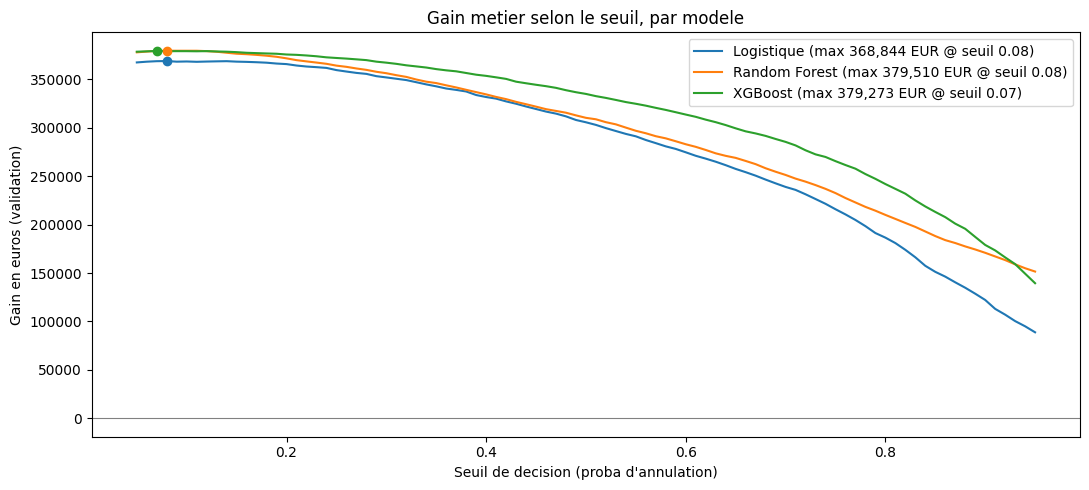

In [19]:
seuils = np.linspace(0.05, 0.95, 91)

def optimiser_seuil(model, X, y, adr):
    proba = model.predict_proba(X)[:, 1]
    y_arr, adr_arr = y.values, adr.values
    gains = [(s, *gain_euros(y_arr, proba, adr_arr, s)) for s in seuils]
    g = pd.DataFrame(gains, columns=["seuil", "gain_eur", "n_appels"])
    best = g.loc[g["gain_eur"].idxmax()]
    return g, best

resultats = {}
plt.figure(figsize=(11, 5))
for nom, m in modeles.items():
    g, best = optimiser_seuil(m, X_val, y_val, adr_val)
    resultats[nom] = best
    plt.plot(g["seuil"], g["gain_eur"], label=f"{nom} (max {best.gain_eur:,.0f} EUR @ seuil {best.seuil:.2f})")
    plt.scatter([best.seuil], [best.gain_eur], zorder=5)

plt.axhline(0, color="grey", lw=0.8)
plt.xlabel("Seuil de decision (proba d'annulation)")
plt.ylabel("Gain en euros (validation)")
plt.title("Gain metier selon le seuil, par modele")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Comparaison finale des trois modeles

On rassemble, pour chaque modele : le gain optimal en euros, le seuil associe, le nombre d'appels,
et les metriques classiques. C'est le tableau de decision.

               seuil   gain_eur  n_appels  precision  recall    f1  roc_auc
Random Forest  0.080 379509.821 15519.000      0.875   0.796 0.834    0.952
XGBoost        0.070 379272.668 16238.000      0.800   0.856 0.827    0.945
Logistique     0.080 368843.864 19711.000      0.715   0.781 0.746    0.885


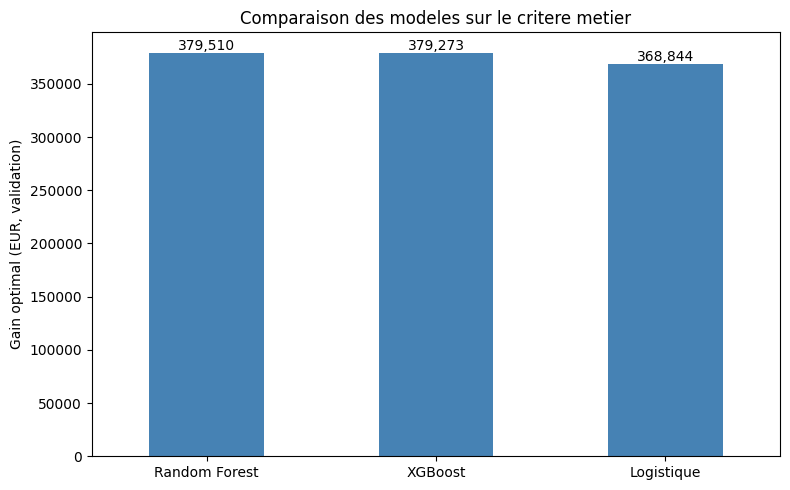

Meilleur modele : Random Forest | seuil optimal : 0.08


In [20]:
compa = pd.DataFrame(resultats).T[["seuil", "gain_eur", "n_appels"]]
compa = compa.join(stats)
compa = compa.sort_values("gain_eur", ascending=False)
print(compa)

ax = compa["gain_eur"].plot(kind="bar", figsize=(8, 5), color="steelblue", rot=0)
ax.set_ylabel("Gain optimal (EUR, validation)")
ax.set_title("Comparaison des modeles sur le critere metier")
for i, v in enumerate(compa["gain_eur"]):
    ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

meilleur_nom = compa.index[0]
meilleur = modeles[meilleur_nom]
seuil_opt = compa.loc[meilleur_nom, "seuil"]
print("Meilleur modele :", meilleur_nom, "| seuil optimal :", round(seuil_opt, 2))

In [25]:
from sklearn.model_selection import GridSearchCV

# Grille volontairement compacte (chaque combinaison = un entraînement, ça monte vite)
param_grid = {
    "n_estimators":     [300, 500],
    "max_depth":        [4, 6, 8],
    "learning_rate":    [0.05, 0.1],
    "subsample":        [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

xgb_base = XGBClassifier(scale_pos_weight=scale_pos, eval_metric="logloss",
                         random_state=42, n_jobs=-1)

grid = GridSearchCV(
    xgb_base, param_grid,
    scoring="roc_auc",      # ou "f1" ; on optimisera le seuil métier après
    cv=3,                   # 3 plis suffisent vu la taille
    n_jobs=-1, verbose=1)

grid.fit(X_train, y_train)

print("Meilleurs paramètres :", grid.best_params_)
print("Meilleur AUC (CV) :", round(grid.best_score_, 4))

xgb_opt = grid.best_estimator_   # le modèle affiné

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Meilleurs paramètres : {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 500, 'subsample': 1.0}
Meilleur AUC (CV) : 0.9467


In [26]:
g, best = optimiser_seuil(xgb_opt, X_val, y_val, adr_val)
print(f"XGBoost affiné — gain optimal : {best.gain_eur:,.0f} EUR @ seuil {best.seuil:.2f}")

XGBoost affiné — gain optimal : 379,147 EUR @ seuil 0.07


## 7. Contrainte des 60 appels/jour

Le seuil optimal peut impliquer plus de 60 appels/jour. Si c'est le cas, on **priorise** : on
appelle d'abord les reservations a plus forte valeur attendue (`proba x prix`), dans la limite du
budget. On estime ici le volume quotidien implique pour verifier si la contrainte est active.

In [21]:
# Estimation du volume quotidien (le dataset couvre ~793 jours : juil. 2015 - aout 2017)
N_JOURS = 793
proba_val = meilleur.predict_proba(X_val)[:, 1]
n_appels_opt = (proba_val >= seuil_opt).sum()
# mise a l'echelle : la validation ne represente qu'une partie des reservations
part_val = len(X_val) / 119208
appels_jour = n_appels_opt / (N_JOURS * part_val)
print(f"Appels/jour impliques au seuil optimal : {appels_jour:.0f} (plafond : {MAX_APPELS_JOUR})")

if appels_jour > MAX_APPELS_JOUR:
    print(">> Contrainte active : on priorise par valeur attendue (proba x prix).")
else:
    print(">> Contrainte respectee : aucun arbitrage necessaire.")

Appels/jour impliques au seuil optimal : 98 (plafond : 60)
>> Contrainte active : on priorise par valeur attendue (proba x prix).


## 8. Evaluation finale sur le test

On applique le modele retenu et son seuil optimal au jeu de test, jamais utilise jusqu'ici.

In [22]:
proba_test = meilleur.predict_proba(X_test)[:, 1]
gain_test, n_app_test = gain_euros(y_test.values, proba_test, adr_test.values, seuil_opt)
pred_test = (proba_test >= seuil_opt).astype(int)

print("=== Resultat final sur le TEST ===")
print(f"Modele        : {meilleur_nom}")
print(f"Seuil         : {seuil_opt:.2f}")
print(f"Gain metier   : {gain_test:,.0f} EUR  ({n_app_test} appels)")
print(f"Gain / appel  : {gain_test / max(n_app_test,1):.2f} EUR")
print(f"ROC-AUC       : {roc_auc_score(y_test, proba_test):.3f}")
print(f"Recall        : {recall_score(y_test, pred_test):.3f}")
print(f"F1            : {f1_score(y_test, pred_test):.3f}")

print("\n", classification_report(y_test, pred_test, target_names=["Honoree", "Annulee"]))

=== Resultat final sur le TEST ===
Modele        : Random Forest
Seuil         : 0.08
Gain metier   : 380,920 EUR  (15550 appels)
Gain / appel  : 24.50 EUR
ROC-AUC       : 0.953
Recall        : 0.988
F1            : 0.716

               precision    recall  f1-score   support

     Honoree       0.99      0.55      0.70     15002
     Annulee       0.56      0.99      0.72      8839

    accuracy                           0.71     23841
   macro avg       0.77      0.77      0.71     23841
weighted avg       0.83      0.71      0.71     23841



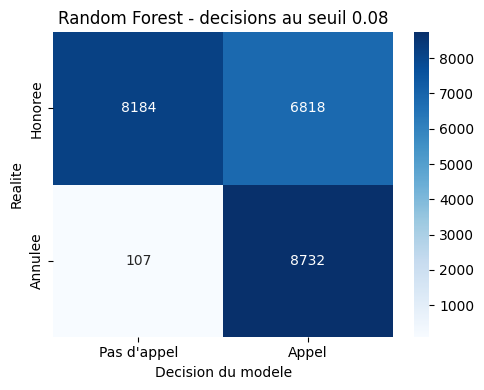

In [23]:
# Matrice de confusion au seuil optimal
cm = confusion_matrix(y_test, pred_test)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pas d'appel", "Appel"], yticklabels=["Honoree", "Annulee"])
plt.title(f"{meilleur_nom} - decisions au seuil {seuil_opt:.2f}")
plt.ylabel("Realite"); plt.xlabel("Decision du modele")
plt.tight_layout()
plt.show()

## 9. Conclusion

A completer apres execution :
- Modele retenu et gain en euros sur le test (valeur economique reelle du modele).
- Comparaison avec le scenario "sans modele" (perte des chambres annulees non anticipees).
- Effet du seuil : un seuil bas attrape plus d'annulations (recall eleve) au prix de plus
  d'appels ; le seuil optimal equilibre selon les couts reels.
- Pistes : reglage fin des hyperparametres, ajustement des parametres metier (taux de revente,
  cout d'appel) pour tester la sensibilite du gain.

In [24]:
# Importance des variables du Random Forest
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
print(importances.sort_values(ascending=False).head(15))

country_freq                    0.130
lead_time                       0.102
log_lead_time                   0.099
adr                             0.077
arrival_date_day_of_month       0.052
arrival_date_week_number        0.052
total_of_special_requests       0.043
total_nights                    0.035
market_segment_Online TA        0.030
stays_in_week_nights            0.029
has_special_requests            0.029
arrival_date_year               0.026
customer_type_Transient         0.026
market_segment_Offline TA/TO    0.021
customer_type_Transient-Party   0.019
dtype: float64


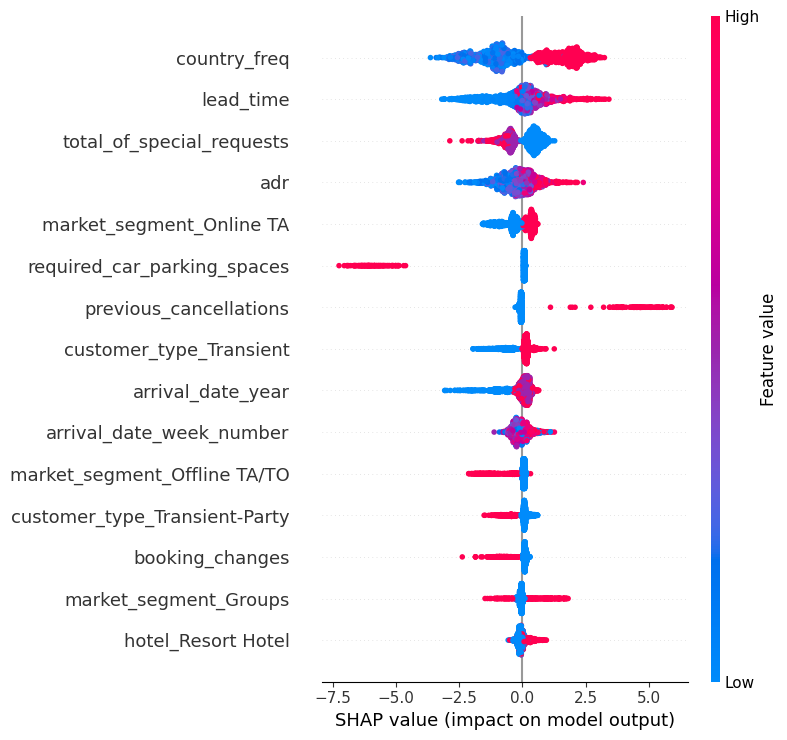

In [27]:
import shap

# Le modèle final retenu (adapte le nom si besoin : xgb_opt ou meilleur)
modele_final = xgb_opt

# TreeExplainer : rapide et exact pour les modèles à arbres (XGBoost, RF)
explainer = shap.TreeExplainer(modele_final)

# On calcule les valeurs SHAP sur un échantillon du test (2000 lignes suffisent
# et c'est beaucoup plus rapide que sur tout le jeu)
X_sample = X_test.sample(n=min(2000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_sample)

# Vue globale : importance + sens de l'effet de chaque variable
shap.summary_plot(shap_values, X_sample, max_display=15)

In [29]:
# Expliquer une réservation précise : pourquoi le modèle recommande (ou non) l'appel
i = 0   # change l'indice pour examiner une autre réservation

reservation = X_sample.iloc[[i]]
proba = modele_final.predict_proba(reservation)[0, 1]
print(f"Risque d'annulation prédit : {proba*100:.0f} %\n")

# Contributions de chaque variable pour CETTE réservation
contrib = pd.Series(shap_values[i], index=X_sample.columns)
contrib = contrib.reindex(contrib.abs().sort_values(ascending=False).index)

print("Principales raisons (les 5 plus fortes) :")
for var, val in contrib.head(5).items():
    sens = "augmente" if val > 0 else "diminue"
    print(f"  - {var:30s} {sens} le risque (impact {val:+.2f})")

Risque d'annulation prédit : 22 %

Principales raisons (les 5 plus fortes) :
  - country_freq                   diminue le risque (impact -1.63)
  - total_of_special_requests      diminue le risque (impact -0.83)
  - lead_time                      augmente le risque (impact +0.54)
  - market_segment_Online TA       augmente le risque (impact +0.37)
  - arrival_date_week_number       diminue le risque (impact -0.32)


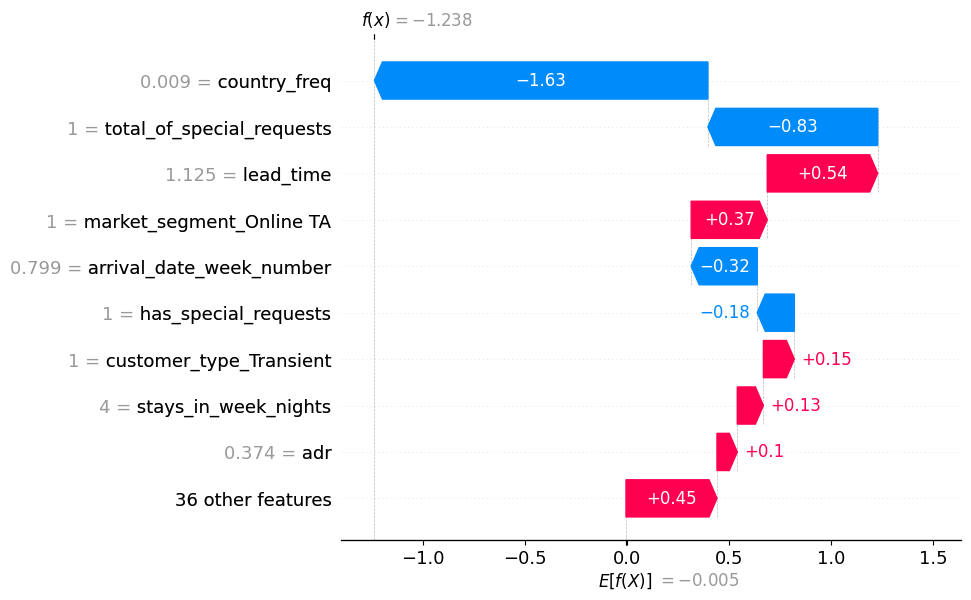

In [31]:
# Visualisation waterfall pour la même réservation
shap.plots.waterfall(
    shap.Explanation(values=shap_values[i],
                     base_values=explainer.expected_value,   # base_valueS avec un s
                     data=X_sample.iloc[i],
                     feature_names=X_sample.columns.tolist()),
    max_display=10)